In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
import scipy
import statsmodels

In [2]:
metrics = ["degree_centralities", "clustering_coefs", "node_bcs"]

Degree:

In [3]:
t = pd.read_csv("metrics_data/data/degree_centralities.csv")
t = t[t.columns[1:]].fillna(0)
p = pd.read_csv("metrics_data/data/protein_degree_centralities.csv")
p = p[p.columns[1:]].fillna(0)

common_cols = list(set(t.columns)&set(p.columns))

t = t[common_cols]
p = p[common_cols]

file_names = {"GSM7454068_V350003741_L01_81_0_network.csv":1, "GSM7454069_V350003741_L01_82_0_network.csv":2,
              "GSM7454070_V350003741_L01_83_0_network.csv":3,
          "GSM7454071_V350003741_L01_84_0_network.csv":4, "GSM7454072_V350003741_L01_85_0_network.csv":5,
              "GSM7454073_V350003741_L01_86_0_network.csv":6,
          "GSM7454074_V350003741_L01_87_0_network.csv":7, "GSM7454075_V350003741_L01_88_0_network.csv":8,
              "GSM7454076_V350003741_L01_73_0_network.csv":9}

file_names_protein = {"protein_g-1 _network.csv":1, "protein_g-3_network.csv":3,
          "protein_g-4_network.csv":4, "protein_g-5_network.csv":5,
              "protein_g-6_network.csv":6,
          "protein_g-7_network.csv":7, "protein_g-8_network.csv":8,
              "protein_g-9_network.csv":9}

t["file_name"] = t["file_name"].map(file_names)
p["file_name"] = p["file_name"].map(file_names_protein)

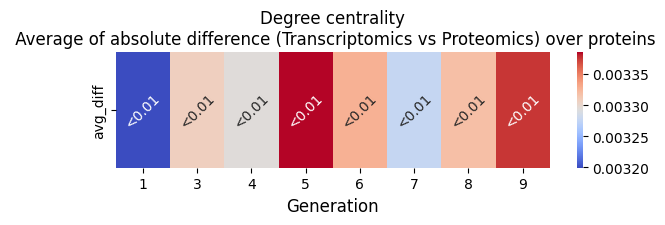

In [5]:
plt.figure(figsize=(7,1.5))
t_aligned = t.set_index("file_name")
p_aligned = p.set_index("file_name")
t_aligned, p_aligned = t_aligned.align(p_aligned, join="inner", axis=0)

diffs = abs(t_aligned-p_aligned)
diffs_avg = diffs.mean(axis=1).to_frame("avg_diff").T
labels = diffs_avg.copy()

labels = labels.applymap(lambda x: "<0.01" if x < 0.01 else f"{x:.2f}")
sns.heatmap(diffs_avg, annot=labels, cmap="coolwarm", annot_kws={"rotation": 45}, fmt="")
plt.title("Degree centrality\n Average of absolute difference (Transcriptomics vs Proteomics) over proteins")
plt.xlabel("Generation", fontsize=12)
plt.savefig("figures/cell_line_local_heatmap.pdf", bbox_inches='tight')

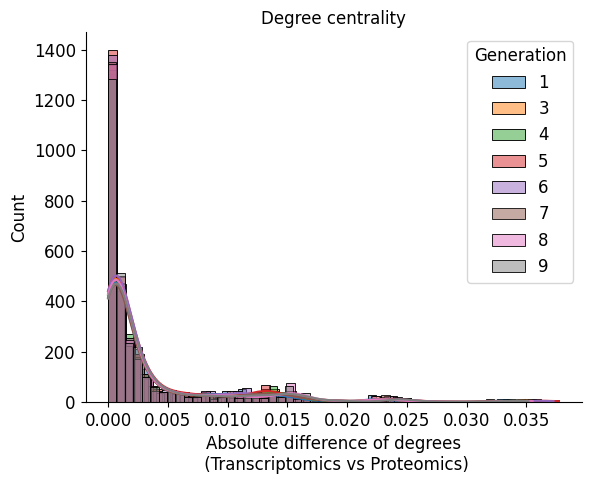

In [6]:
matplotlib.rcParams.update({'font.size': 12})
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:grey"]
j=0
for i,row in diffs.iterrows():
    sns.histplot(row, kde=True, label=i, color=colors[j], bins=50)
    j+=1
plt.legend(title="Generation")
sns.despine()
plt.xlabel("Absolute difference of degrees\n (Transcriptomics vs Proteomics)")
plt.title("Degree centrality", fontsize=12)
plt.savefig("figures/cell_line_local_hist.pdf", bbox_inches='tight')

Clustering:

In [7]:
t = pd.read_csv("metrics_data/data/clustering_coefs.csv")
t = t[t.columns[1:]].fillna(0)
p = pd.read_csv("metrics_data/data/protein_clustering_coefs.csv")
p = p[p.columns[1:]].fillna(0)

common_cols = list(set(t.columns)&set(p.columns))

t = t[common_cols]
p = p[common_cols]

file_names = {"GSM7454068_V350003741_L01_81_0_network.csv":1, "GSM7454069_V350003741_L01_82_0_network.csv":2,
              "GSM7454070_V350003741_L01_83_0_network.csv":3,
          "GSM7454071_V350003741_L01_84_0_network.csv":4, "GSM7454072_V350003741_L01_85_0_network.csv":5,
              "GSM7454073_V350003741_L01_86_0_network.csv":6,
          "GSM7454074_V350003741_L01_87_0_network.csv":7, "GSM7454075_V350003741_L01_88_0_network.csv":8,
              "GSM7454076_V350003741_L01_73_0_network.csv":9}

file_names_protein = {"protein_g-1 _network.csv":1, "protein_g-3_network.csv":3,
          "protein_g-4_network.csv":4, "protein_g-5_network.csv":5,
              "protein_g-6_network.csv":6,
          "protein_g-7_network.csv":7, "protein_g-8_network.csv":8,
              "protein_g-9_network.csv":9}

t["file_name"] = t["file_name"].map(file_names)
p["file_name"] = p["file_name"].map(file_names_protein)

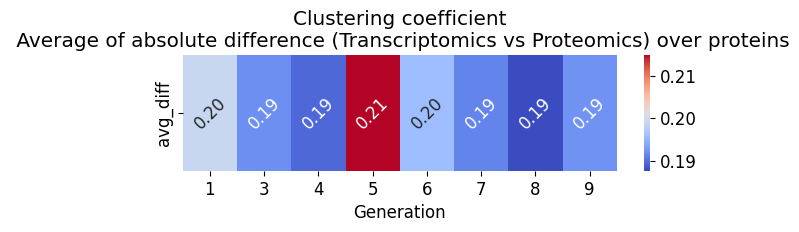

In [8]:
plt.figure(figsize=(7,1.5))
t_aligned = t.set_index("file_name")
p_aligned = p.set_index("file_name")
t_aligned, p_aligned = t_aligned.align(p_aligned, join="inner", axis=0)

diffs = abs(t_aligned-p_aligned)
diffs_avg = diffs.mean(axis=1).to_frame("avg_diff").T
labels = diffs_avg.copy()

labels = labels.applymap(lambda x: "<0.01" if x < 0.01 else f"{x:.2f}")
sns.heatmap(diffs_avg, annot=labels, cmap="coolwarm", annot_kws={"rotation": 45}, fmt="")
plt.title("Clustering coefficient\n Average of absolute difference (Transcriptomics vs Proteomics) over proteins")
plt.xlabel("Generation", fontsize=12)
plt.savefig("figures/cell_line_local_heatmap_clustering.pdf", bbox_inches='tight')

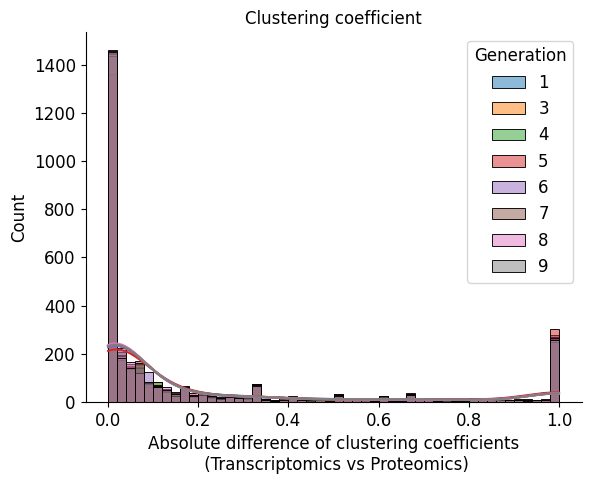

In [9]:
matplotlib.rcParams.update({'font.size': 12})
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:grey"]
j=0
for i,row in diffs.iterrows():
    sns.histplot(row, kde=True, label=i, color=colors[j], bins=50)
    j+=1
plt.legend(title="Generation")
sns.despine()
plt.xlabel("Absolute difference of clustering coefficients\n (Transcriptomics vs Proteomics)")
plt.title("Clustering coefficient", fontsize=12)
plt.savefig("figures/cell_line_local_hist_clustering.pdf", bbox_inches='tight')

Node bcs:

In [10]:
t = pd.read_csv("metrics_data/data/node_bcs.csv")
t = t[t.columns[1:]].fillna(0)
p = pd.read_csv("metrics_data/data/protein_node_bcs.csv")
p = p[p.columns[1:]].fillna(0)

common_cols = list(set(t.columns)&set(p.columns))

t = t[common_cols]
p = p[common_cols]

file_names = {"GSM7454068_V350003741_L01_81_0_network.csv":1, "GSM7454069_V350003741_L01_82_0_network.csv":2,
              "GSM7454070_V350003741_L01_83_0_network.csv":3,
          "GSM7454071_V350003741_L01_84_0_network.csv":4, "GSM7454072_V350003741_L01_85_0_network.csv":5,
              "GSM7454073_V350003741_L01_86_0_network.csv":6,
          "GSM7454074_V350003741_L01_87_0_network.csv":7, "GSM7454075_V350003741_L01_88_0_network.csv":8,
              "GSM7454076_V350003741_L01_73_0_network.csv":9}

file_names_protein = {"protein_g-1 _network.csv":1, "protein_g-3_network.csv":3,
          "protein_g-4_network.csv":4, "protein_g-5_network.csv":5,
              "protein_g-6_network.csv":6,
          "protein_g-7_network.csv":7, "protein_g-8_network.csv":8,
              "protein_g-9_network.csv":9}

t["file_name"] = t["file_name"].map(file_names)
p["file_name"] = p["file_name"].map(file_names_protein)

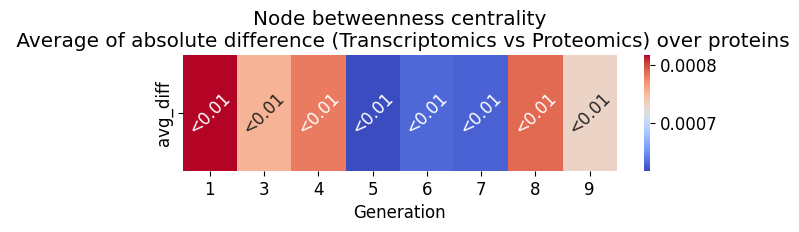

In [11]:
plt.figure(figsize=(7,1.5))
t_aligned = t.set_index("file_name")
p_aligned = p.set_index("file_name")
t_aligned, p_aligned = t_aligned.align(p_aligned, join="inner", axis=0)

diffs = abs(t_aligned-p_aligned)
diffs_avg = diffs.mean(axis=1).to_frame("avg_diff").T
labels = diffs_avg.copy()

labels = labels.applymap(lambda x: "<0.01" if x < 0.01 else f"{x:.2f}")
sns.heatmap(diffs_avg, annot=labels, cmap="coolwarm", annot_kws={"rotation": 45}, fmt="")
plt.title("Node betweenness centrality\n Average of absolute difference (Transcriptomics vs Proteomics) over proteins")
plt.xlabel("Generation", fontsize=12)
plt.savefig("figures/cell_line_local_heatmap_nodebc.pdf", bbox_inches='tight')

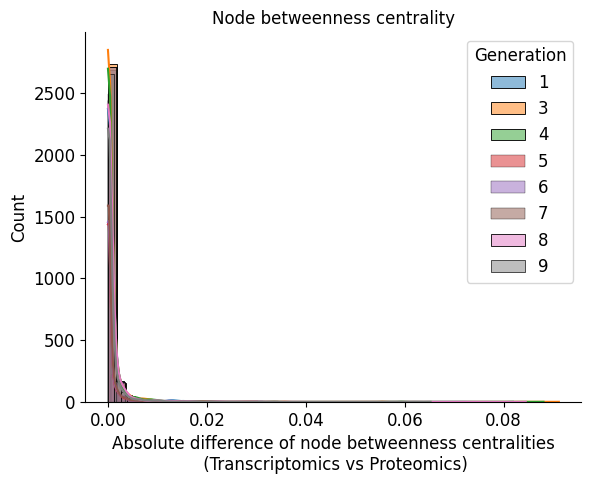

In [12]:
matplotlib.rcParams.update({'font.size': 12})
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:grey"]
j=0
for i,row in diffs.iterrows():
    sns.histplot(row, kde=True, label=i, color=colors[j], bins=50)
    j+=1
plt.legend(title="Generation")
sns.despine()
plt.xlabel("Absolute difference of node betweenness centralities\n (Transcriptomics vs Proteomics)")
plt.title("Node betweenness centrality", fontsize=12)
plt.savefig("figures/cell_line_local_hist_nodebc.pdf", bbox_inches='tight')

## Trend:

In [119]:
df = pd.read_csv("local_tests/cell_line_degree_centralities_tendency.csv.csv")
df["transcriptomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["transcriptomic_pvalue"])[1]
df["proteomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["proteomic_pvalue"])[1]
df["transcriptomic_plot"] = np.sign(df["transcriptomic_coef"])*np.log10(df["transcriptomic_pvalue_fdr"])*(-1)
df["proteomic_plot"] = np.sign(df["proteomic_coef"])*np.log10(df["proteomic_pvalue_fdr"])*(-1)

In [123]:
df[df["transcriptomic_pvalue_fdr"]<0.05]

,node,transcriptomic_coef,transcriptomic_pvalue,proteomic_coef,proteomic_pvalue,transcriptomic_pvalue_fdr,proteomic_pvalue_fdr,transcriptomic_plot,proteomic_plot


In [124]:
df[df["proteomic_pvalue_fdr"]<0.05]

,node,transcriptomic_coef,transcriptomic_pvalue,proteomic_coef,proteomic_pvalue,transcriptomic_pvalue_fdr,proteomic_pvalue_fdr,transcriptomic_plot,proteomic_plot


After FDR correction, none of them are significant.

In [122]:
np.log10(0.05)

-1.3010299956639813

<Axes: xlabel='transcriptomic_plot', ylabel='proteomic_plot'>

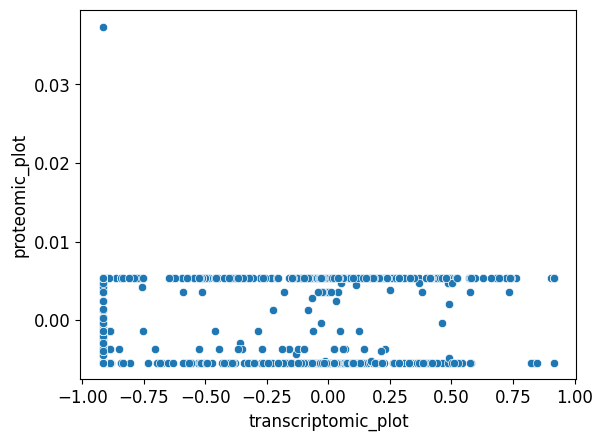

In [121]:
sns.scatterplot(data=df, x="transcriptomic_plot", y="proteomic_plot")

In [135]:
df = pd.read_csv("local_tests/cell_line_clustering_coefs_tendency.csv.csv")
df["transcriptomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["transcriptomic_pvalue"])[1]
df["proteomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["proteomic_pvalue"])[1]
df["transcriptomic_plot"] = np.sign(df["transcriptomic_coef"])*np.log10(df["transcriptomic_pvalue_fdr"])*(-1)
df["proteomic_plot"] = np.sign(df["proteomic_coef"])*np.log10(df["proteomic_pvalue_fdr"])*(-1)

In [136]:
df[df["transcriptomic_pvalue_fdr"]<0.05]

,node,transcriptomic_coef,transcriptomic_pvalue,proteomic_coef,proteomic_pvalue,transcriptomic_pvalue_fdr,proteomic_pvalue_fdr,transcriptomic_plot,proteomic_plot


In [137]:
df[df["proteomic_pvalue_fdr"]<0.05]

,node,transcriptomic_coef,transcriptomic_pvalue,proteomic_coef,proteomic_pvalue,transcriptomic_pvalue_fdr,proteomic_pvalue_fdr,transcriptomic_plot,proteomic_plot


In [138]:
df = pd.read_csv("local_tests/cell_line_node_bcs_tendency.csv.csv")
df["transcriptomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["transcriptomic_pvalue"])[1]
df["proteomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["proteomic_pvalue"])[1]
df["transcriptomic_plot"] = np.sign(df["transcriptomic_coef"])*np.log10(df["transcriptomic_pvalue_fdr"])*(-1)
df["proteomic_plot"] = np.sign(df["proteomic_coef"])*np.log10(df["proteomic_pvalue_fdr"])*(-1)

In [139]:
df[df["transcriptomic_pvalue_fdr"]<0.05]

,node,transcriptomic_coef,transcriptomic_pvalue,proteomic_coef,proteomic_pvalue,transcriptomic_pvalue_fdr,proteomic_pvalue_fdr,transcriptomic_plot,proteomic_plot


In [140]:
df[df["proteomic_pvalue_fdr"]<0.05]

,node,transcriptomic_coef,transcriptomic_pvalue,proteomic_coef,proteomic_pvalue,transcriptomic_pvalue_fdr,proteomic_pvalue_fdr,transcriptomic_plot,proteomic_plot


## Interaction term:

In [22]:
df = pd.read_csv("local_tests/cell_line_degree_centralities_interaction.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["interaction_pvalue"])[1]

In [23]:
df[df["fdr_pvalue"]<0.05]

,node,interaction_coef,interaction_pvalue,fdr_pvalue
499,9606.ENSP00000419005,0.000119,0.000002,0.00463


UTP25: interaction term is sign. --> time-related trend of degree in transcriptomic and proteomic network is different (not parallel).

In [24]:
len(df)

3019

In [25]:
df = pd.read_csv("local_tests/cell_line_clustering_coefs_interaction.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["interaction_pvalue"])[1]

In [26]:
df[df["fdr_pvalue"]<0.05]

,node,interaction_coef,interaction_pvalue,fdr_pvalue
1087,9606.ENSP00000296509,-0.003793,0.000004,0.011423


MAD2L1:interaction term is sign. --> time-related trend of clustering coef in transcriptomic and proteomic network is different (not parallel).

In [27]:
len(df)

3019

In [28]:
df = pd.read_csv("local_tests/cell_line_node_bcs_interaction.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["interaction_pvalue"])[1]

In [29]:
df[df["fdr_pvalue"]<0.05]

,node,interaction_coef,interaction_pvalue,fdr_pvalue


In [30]:
len(df)

3019

## Randomized test:

In [14]:
df = pd.read_csv("local_tests/cell_line_degree_centralities_randomized.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["p_value"])[1]

In [15]:
len(df[df["fdr_pvalue"]<0.05]), len(df[df["p_value"]<0.01]), len(df)

(49, 200, 3019)

In [16]:
(49/3019)*100

1.6230539913878768

In [17]:
df = pd.read_csv("local_tests/cell_line_clustering_coefs_randomized.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["p_value"])[1]

In [18]:
len(df[df["fdr_pvalue"]<0.05]), len(df[df["p_value"]<0.01]), len(df)

(1368, 1312, 3019)

In [19]:
(1368/3019)*100

45.31301755548195

In [20]:
df = pd.read_csv("local_tests/cell_line_node_bcs_randomized.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["p_value"])[1]

In [21]:
len(df[df["fdr_pvalue"]<0.05]), len(df[df["p_value"]<0.01]), len(df)

(1481, 1388, 3019)

In [22]:
(1481/3019)*100

49.055978800927456

In [23]:
res = pd.DataFrame({"metric":["degree_centralities", "degree_centralities", "clustering_coefs", "clustering_coefs", "node_bcs", "node_bcs"], 
                    "num_sign":[49, 3019-49,1368, 3019-1368,1481, 3019-1481],
                    "sign":[True,False,True,False,True,False]})
res

,metric,num_sign,sign
0,degree_centralities,49,True
1,degree_centralities,2970,False
2,clustering_coefs,1368,True
3,clustering_coefs,1651,False
4,node_bcs,1481,True
5,node_bcs,1538,False


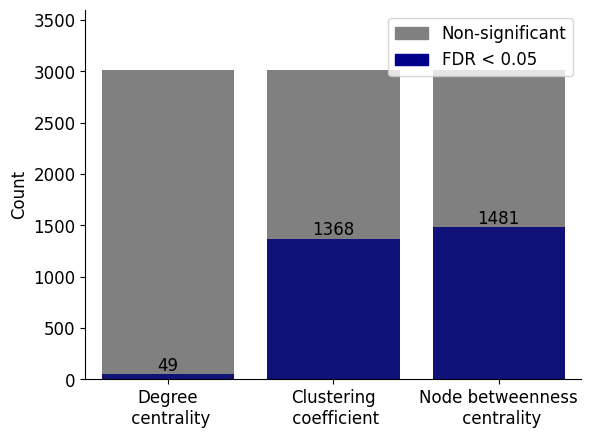

In [24]:
import matplotlib.patches as mpatches

matplotlib.rcParams.update({'font.size': 12})

total = res.groupby('metric')['num_sign'].sum().reset_index()
bar1 = sns.barplot(x="metric",  y="num_sign", data=total, color='grey')
bar2 = sns.barplot(x="metric",  y="num_sign", data=res[res["sign"]==True], color='darkblue')
bar2.bar_label(bar2.containers[1], fontsize=12);

top_bar = mpatches.Patch(color='grey', label='Non-significant')
bottom_bar = mpatches.Patch(color='darkblue', label='FDR < 0.05')
plt.legend(handles=[top_bar, bottom_bar], loc=1)

sns.despine()
plt.ylim(0,3600)
plt.ylabel("Count")
plt.xlabel("")
plt.xticks([0,1,2], ["Degree\n centrality", "Clustering\n coefficient", "Node betweenness\n centrality"])
plt.savefig("figures/cell_line_local_randomized.pdf", bbox_inches='tight')